In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

from scipy.signal import correlate2d
from scipy.interpolate import RegularGridInterpolator

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


* Ensuring proper sampling, wavefield size, and boundary conditions
* *Simulate and save phase mask with proper sizes*
    * *Try different densities of structures*
    * *Compare outputs from different samplings*
* Ensure proper simulation w.r.t. medium RIs
* Compare BPM vs Thin sample modeling
    * *Make videos for propagation distances*
* Problem specification: FOV and same sampling, but spatial resolution/ spatial frequency limited by distance and speckle size?
    * Speckle size increases with distance?

In [69]:
# Grid and propagation parameters setup
wl = 640e-9
spatial_resolution = [500e-9, 500e-9, 50e-9] # dx, dy, dz
grid_shape = [500, 500, 500] # x=0->, y=0->, z=0->
n_background = 1. # immersion medium RI
spatial_support = [spatial_resolution[i]*grid_shape[i] for i in range(3)]

In [ ]:
# Create the Geometry object with a shared grid
geom = geometry.Geometry(grid_shape, spatial_resolution, n_background)

plane_pnt = [0, 0, 10e-6]
plane_normal = [0, 0, 1]

num = 125 # create num elemets
for i in range(num):
    print(f"Shapes: {i+1}/{num}", end="\r")
    pos_x, pos_y = np.random.uniform(6, 244, size=2)
    pos_x, pos_y = pos_x*1e-6, pos_y*1e-6
    geom.add_obj_on_plane('cube', (pos_x, pos_y), length=10e-6, RI=1.4609, 
                              plane=[plane_pnt, plane_normal], bias=2.75e-6)

geom.add_plane(point=plane_pnt, normal=plane_normal, RI=1.49, thickness=15e-6)

# Retrieve 3d RI distribution
RI_distribution = geom.get_grid()
print('Geometry: Done')

Coordiante system with size: 
 
              X = [0, 2.50e-04], Res_X = 5e-07
              Y = [0, 2.50e-04], Res_Y = 5e-07
              Z = [0, 2.50e-05], Res_Z = 5e-08
              Immersion RI: 1.0
      
Geometry: Done5


In [71]:

# visualization
visualization.visualize_grid_vol(RI_distribution[::2, ::2, ::2], n_background=n_background, factor=1)

# # saving object
# geom.save('examples/data/geometry/v8_diffuser_geom.pkl')

# del geom

# # loading geom
# geom2 = utils.load_pkl('examples/data/geometry/v8_diffuser_geom.pkl')

# visualization
# visualization.visualize_grid_vol(geom2.get_grid(), n_background=geom2.n_0, factor=2)


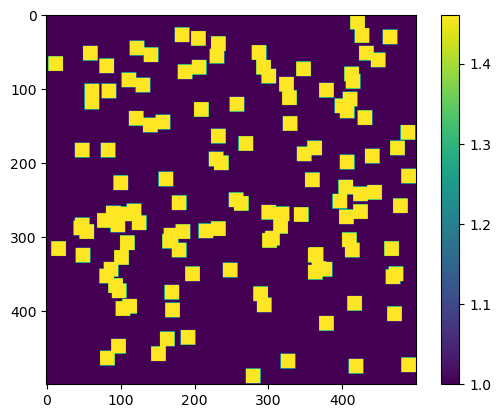

In [72]:
RI_dist = geom.get_grid()[:, :, 46:200]
nx, ny, nz = geom.nx, geom.ny, geom.nz
dx, dy, dz = geom.dx, geom.dy, geom.dz

plt.imshow(RI_dist[:, :, 0])
plt.colorbar()
plt.show()

In [73]:
RI_dist.shape, np.unique(RI_dist[:, :, 0]), np.unique(RI_dist[:, :, 10]), np.unique(RI_dist)

((500, 500, 154),
 array([1.    , 1.4609]),
 array([1.49]),
 array([1.    , 1.4609, 1.49  ]))

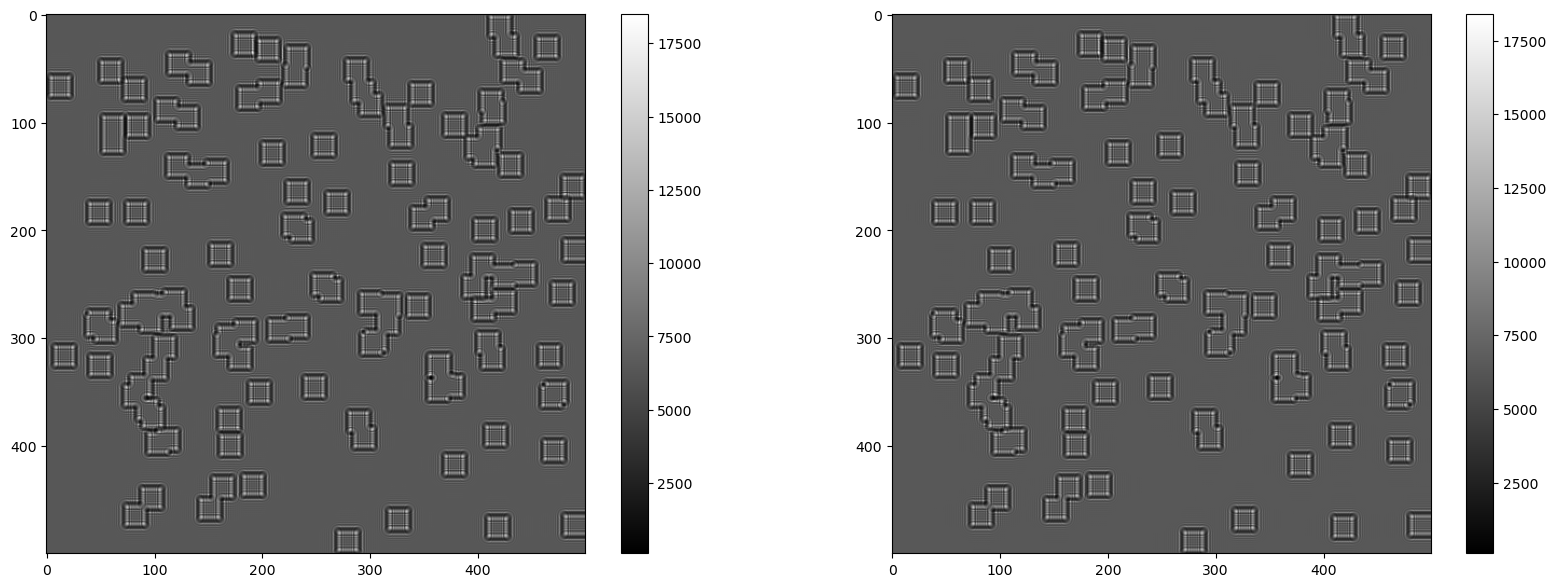

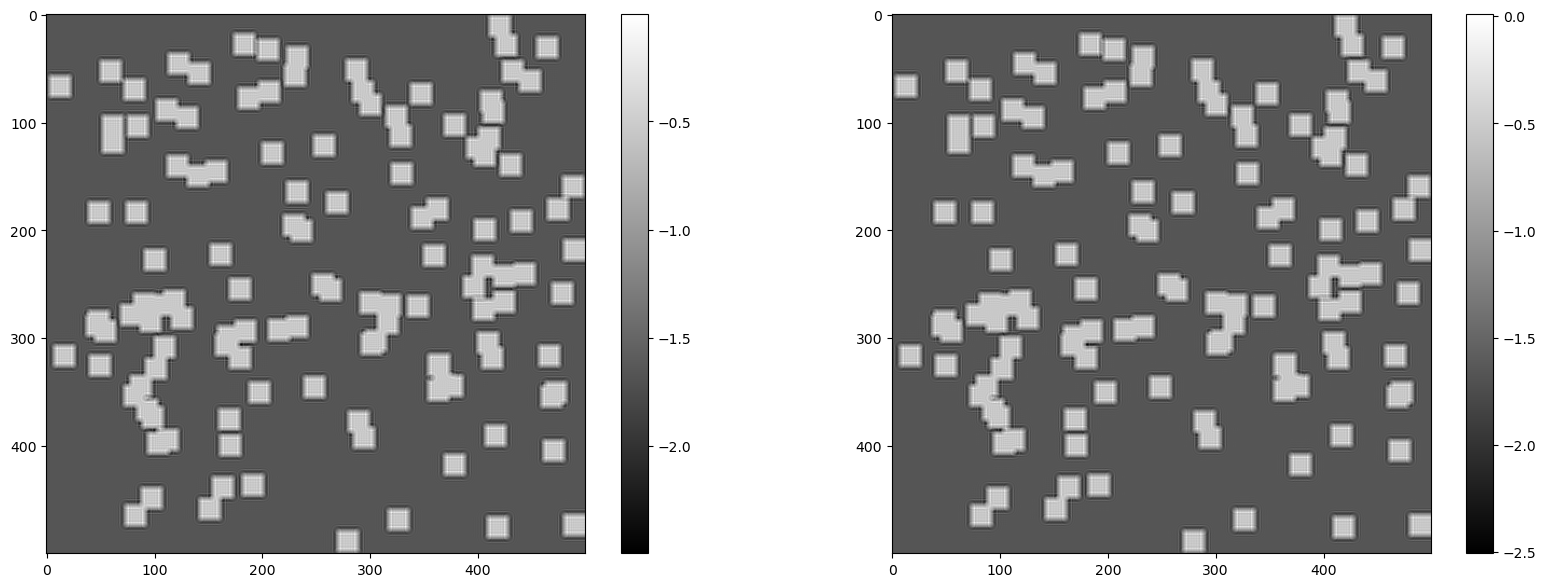

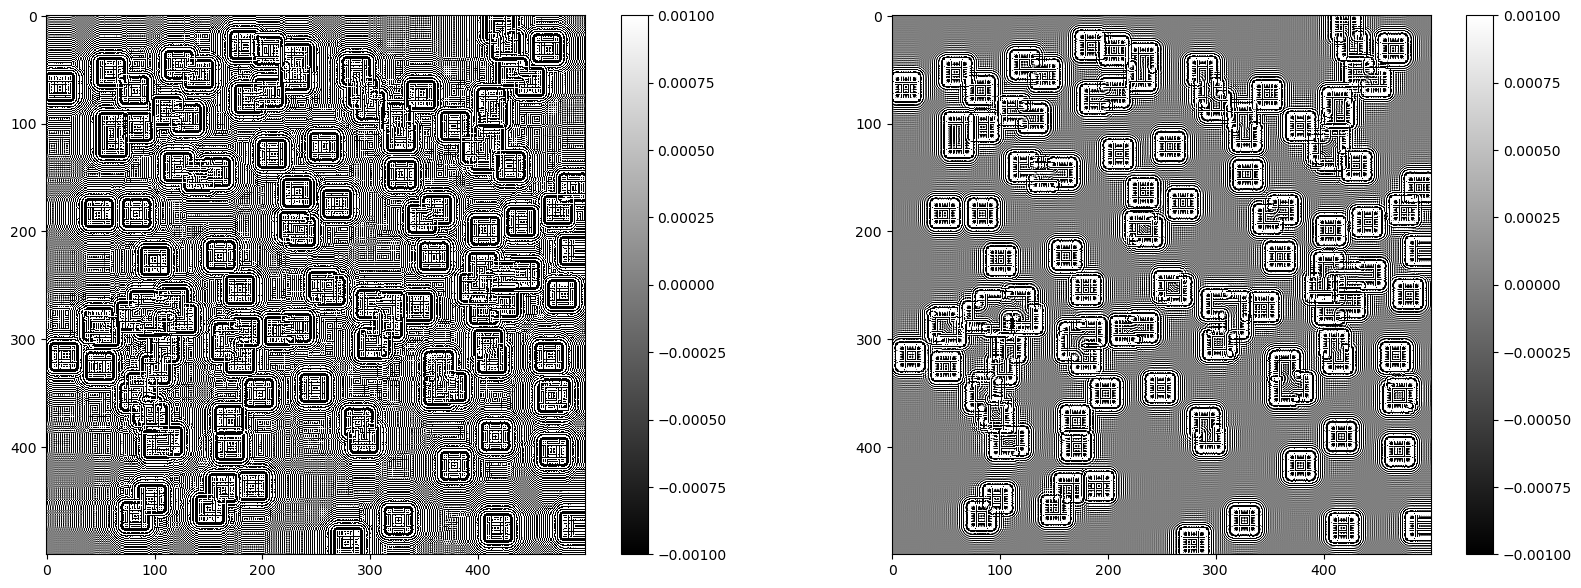

In [74]:
field = np.zeros([nx, ny])
field[:, :] = 80

# Propagate and visualize
output_field = propagator.propagate_beam_2(field, RI_dist, 1.49, wl, [dx, dy, dz], padding=512)

phase_delay = RI_dist[:, :, 0]*50e-9*5*-1
output_field_2 = propagator.propagate(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*5, padding=512)
# *np.exp(-1j*(2*np.pi/wl)*50*50e-9)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_2)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.angle(output_field), cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field_2), cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field) - np.abs(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field) - np.angle(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
plt.colorbar(cm1, ax=axs[1])

plt.show()

(1012, 1012)

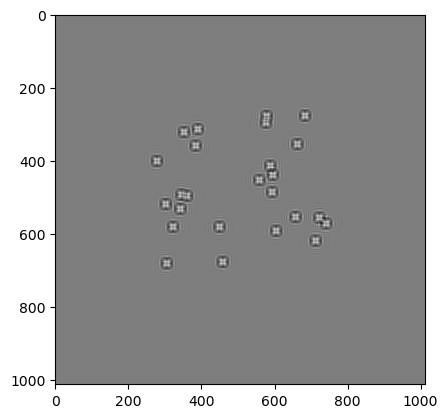

In [67]:
output_field_2_check = propagator.propagate(np.pad(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), 256, 'edge'), 
                                            wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 + 50e-6, padding=None)

plt.imshow(np.abs(output_field_2_check), cmap='gray')
output_field_2_check.shape

In [75]:
# cap = cv2.VideoCapture(0)

# # Define the codec and create VideoWriter object
# #fourcc = cv2.cv.CV_FOURCC(*'DIVX')
# #out = cv2.VideoWriter('output.avi',fourcc, 20.0, (640,480))
# out = cv2.VideoWriter('10um_3_mask_prop_abs.avi', cv2.VideoWriter_fourcc(*'XVID'), 20, (1012, 1012), isColor=False)

# for i in range(1, 2000, 10):
#     frame = propagator.propagate(np.pad(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), 256, 'edge'), 
#                                  wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*5 + i*1e-6, padding=None)
    
#     frame = np.abs(frame)
#     frame = np.array(((frame - frame.min())/(frame.max() - frame.min()))*255, dtype=np.uint8)

#     # write the flipped frame
#     out.write(frame)

# # Release everything if job is finished
# out.release()

In [59]:
500*200e-9/1e-6

100.0